# Objetivo 4 - Entrenamiento GPU (RTX 5060)
AMP activo. Ambos datasets, todos los modelos.

## 0 - Instalacion

In [1]:
import subprocess,sys
subprocess.run([sys.executable,'-m','pip','install','-q','torch','torchvision','--index-url','https://download.pytorch.org/whl/cu128'],check=False)
subprocess.run([sys.executable,'-m','pip','install','-q','pennylane>=0.38','pennylane-lightning','scikit-learn','pandas','matplotlib','seaborn','tqdm'],check=False)
import torch
print('PyTorch:',torch.__version__)
print('CUDA:',torch.cuda.is_available())
if torch.cuda.is_available(): print('GPU:',torch.cuda.get_device_name(0))


PyTorch: 2.11.0+cu128
CUDA: True
GPU: NVIDIA GeForce RTX 5060 Laptop GPU


## 1 - Imports y seed

In [2]:
import os,random,time,json
from pathlib import Path
from itertools import combinations
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import torchvision.transforms as T
from torchvision.datasets import ImageFolder
from torchvision.models import resnet18,ResNet18_Weights
from torch.utils.data import DataLoader,WeightedRandomSampler
import pennylane as qml
from pennylane.qnn import TorchLayer
from tqdm.notebook import tqdm
from sklearn.metrics import accuracy_score,f1_score,classification_report,confusion_matrix,roc_auc_score,recall_score
from scipy import stats
SEED=42
random.seed(SEED);np.random.seed(SEED)
torch.manual_seed(SEED);torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.benchmark=True
torch.backends.cudnn.deterministic=False
torch.backends.cuda.matmul.allow_tf32=True
torch.backends.cudnn.allow_tf32=True
DEVICE=torch.device('cuda' if torch.cuda.is_available() else 'cpu')
assert DEVICE.type=='cuda','GPU no detectada'
print('Device:',DEVICE,'|',torch.cuda.get_device_name(0))


Device: cuda | NVIDIA GeForce RTX 5060 Laptop GPU


## 2 - DataLoaders

In [3]:
BASE_DIR=Path(os.getcwd())
CHEST_OUT=BASE_DIR/'etl_output'/'chest_xray'
LUNG_OUT=BASE_DIR/'etl_output'/'lung_cancer'
CKPT_DIR=BASE_DIR/'checkpoints_gpu'
CKPT_DIR.mkdir(exist_ok=True)
BATCH_SIZE=64
IMG_SIZE=(128,128)
MEAN=[0.485,0.456,0.406];STD=[0.229,0.224,0.225]
tfm_tr=T.Compose([T.Resize(IMG_SIZE),T.Grayscale(num_output_channels=3),T.RandomRotation(10),T.RandomHorizontalFlip(),T.ColorJitter(brightness=0.15),T.RandomAffine(degrees=0,scale=(0.90,1.10)),T.ToTensor(),T.Normalize(MEAN,STD)])
tfm_ev=T.Compose([T.Resize(IMG_SIZE),T.Grayscale(num_output_channels=3),T.ToTensor(),T.Normalize(MEAN,STD)])
def make_loaders(root,weighted=False):
    root=Path(root)
    ds_tr=ImageFolder(root/'train',transform=tfm_tr)
    ds_va=ImageFolder(root/'val',transform=tfm_ev)
    ds_te=ImageFolder(root/'test',transform=tfm_ev)
    kw=dict(num_workers=4,pin_memory=True,persistent_workers=True)
    if weighted:
        tgts=torch.tensor(ds_tr.targets)
        sw=(1.0/torch.bincount(tgts).float())[tgts]
        ltr=DataLoader(ds_tr,batch_size=BATCH_SIZE,sampler=WeightedRandomSampler(sw,len(sw),True),**kw)
    else:
        ltr=DataLoader(ds_tr,batch_size=BATCH_SIZE,shuffle=True,**kw)
    lva=DataLoader(ds_va,batch_size=BATCH_SIZE,shuffle=False,**kw)
    lte=DataLoader(ds_te,batch_size=BATCH_SIZE,shuffle=False,**kw)
    return ltr,lva,lte,ds_tr.class_to_idx
chest_tr_l,chest_va_l,chest_te_l,chest_cls=make_loaders(CHEST_OUT)
lung_tr_l,lung_va_l,lung_te_l,lung_cls=make_loaders(LUNG_OUT,weighted=True)
N_CHEST=len(chest_cls);N_LUNG=len(lung_cls)
tgts=torch.tensor(ImageFolder(LUNG_OUT/'train').targets)
lung_cw=(1.0/torch.bincount(tgts).float())
lung_cw=(lung_cw/lung_cw.sum()).to(DEVICE)
CHEST_NAMES=['NORMAL','PNEUMONIA']
LUNG_NAMES=['Benign','Malignant','Normal']
print('Chest:',chest_cls,'| Lung:',lung_cls)


Chest: {'NORMAL': 0, 'PNEUMONIA': 1} | Lung: {'Benign': 0, 'Malignant': 1, 'Normal': 2}


## 3 - Modelos

In [4]:
N_QUBITS=4
def get_qdev(n):
    try: return qml.device('lightning.qubit',wires=n)
    except: return qml.device('default.qubit',wires=n)
def build_resnet18(nc):
    m=resnet18(weights=ResNet18_Weights.IMAGENET1K_V1)
    m.fc=nn.Sequential(nn.Linear(m.fc.in_features,N_QUBITS),nn.ReLU(),nn.Linear(N_QUBITS,nc))
    return m
dev1=get_qdev(N_QUBITS)
@qml.qnode(dev1,interface='torch',diff_method='adjoint')
def circ1(inputs,weights):
    qml.AngleEmbedding(inputs,wires=range(N_QUBITS),rotation='X')
    qml.StronglyEntanglingLayers(weights,wires=range(N_QUBITS))
    return [qml.expval(qml.PauliZ(i)) for i in range(N_QUBITS)]
class HQCCNN(nn.Module):
    def __init__(self,nc):
        super().__init__()
        self.feat=nn.Sequential(nn.Conv2d(3,16,3,padding=1),nn.BatchNorm2d(16),nn.ReLU(),nn.MaxPool2d(2),nn.Conv2d(16,32,3,padding=1),nn.BatchNorm2d(32),nn.ReLU(),nn.MaxPool2d(2),nn.Conv2d(32,64,3,padding=1),nn.BatchNorm2d(64),nn.ReLU(),nn.AdaptiveAvgPool2d((4,4)))
        self.pre=nn.Sequential(nn.Linear(64*4*4,64),nn.ReLU(),nn.Linear(64,N_QUBITS),nn.Tanh())
        self.ql=TorchLayer(circ1,{'weights':(2,N_QUBITS,3)})
        self.cls=nn.Linear(N_QUBITS,nc)
    def forward(self,x):
        dv=x.device
        x=self.feat(x).flatten(1)
        qi=self.pre(x).float().cpu()*torch.pi
        return self.cls(self.ql(qi).to(dv).to(x.dtype))
dev2=get_qdev(N_QUBITS)
@qml.qnode(dev2,interface='torch',diff_method='adjoint')
def circ2(inputs,weights):
    qml.AngleEmbedding(inputs,wires=range(N_QUBITS),rotation='Y')
    qml.BasicEntanglerLayers(weights,wires=range(N_QUBITS))
    return [qml.expval(qml.PauliZ(i)) for i in range(N_QUBITS)]
class PEQML(nn.Module):
    def __init__(self,nc):
        super().__init__()
        def dw(ic,oc,s=1): return nn.Sequential(nn.Conv2d(ic,ic,3,stride=s,padding=1,groups=ic,bias=False),nn.Conv2d(ic,oc,1,bias=False),nn.BatchNorm2d(oc),nn.ReLU6())
        self.feat=nn.Sequential(nn.Conv2d(3,8,3,stride=2,padding=1,bias=False),nn.BatchNorm2d(8),nn.ReLU6(),dw(8,16,2),dw(16,32,2),dw(32,32,2),nn.AdaptiveAvgPool2d((2,2)))
        self.pre=nn.Sequential(nn.Linear(32*2*2,N_QUBITS),nn.Tanh())
        self.ql=TorchLayer(circ2,{'weights':(2,N_QUBITS)})
        self.cls=nn.Linear(N_QUBITS,nc)
    def forward(self,x):
        dv=x.device
        x=self.feat(x).flatten(1)
        qi=self.pre(x).float().cpu()*torch.pi
        return self.cls(self.ql(qi).to(dv).to(x.dtype))
def _hql(nl):
    dev=get_qdev(N_QUBITS)
    @qml.qnode(dev,interface='torch',diff_method='adjoint')
    def circ(inputs,weights_rx,weights_ry,weights_rz):
        qml.AngleEmbedding(inputs,wires=range(N_QUBITS),rotation='X')
        for l in range(nl):
            for q in range(N_QUBITS):
                qml.RX(weights_rx[l,q],wires=q)
                qml.RY(weights_ry[l,q],wires=q)
                qml.RZ(weights_rz[l,q],wires=q)
            for i in range(N_QUBITS-1): qml.CNOT(wires=[i,i+1])
        return [qml.expval(qml.PauliZ(i)) for i in range(N_QUBITS)]
    ws={k:(nl,N_QUBITS) for k in ['weights_rx','weights_ry','weights_rz']}
    return TorchLayer(circ,ws)
class HQCINN(nn.Module):
    V={'shallow':1,'deep':3}
    def __init__(self,nc,variant='shallow'):
        super().__init__()
        self.feat=nn.Sequential(nn.Conv2d(3,32,3,padding=1),nn.BatchNorm2d(32),nn.ReLU(),nn.MaxPool2d(2),nn.Conv2d(32,64,3,padding=1),nn.BatchNorm2d(64),nn.ReLU(),nn.MaxPool2d(2),nn.Conv2d(64,128,3,padding=1),nn.BatchNorm2d(128),nn.ReLU(),nn.AdaptiveAvgPool2d((2,2)))
        self.pre=nn.Sequential(nn.Linear(128*2*2,N_QUBITS),nn.Tanh())
        self.ql=_hql(self.V[variant])
        self.cls=nn.Linear(N_QUBITS,nc)
    def forward(self,x):
        dv=x.device
        x=self.feat(x).flatten(1)
        qi=self.pre(x).float().cpu()*torch.pi
        return self.cls(self.ql(qi).to(dv).to(x.dtype))
def build_model(name,nc):
    if name=='resnet18': return build_resnet18(nc)
    elif name=='hqccnn': return HQCCNN(nc)
    elif name=='peqml': return PEQML(nc)
    elif name=='hqcinn_shallow': return HQCINN(nc,variant='shallow')
    elif name=='hqcinn_deep': return HQCINN(nc,variant='deep')
    else: raise ValueError(name)
MODEL_NAMES=['resnet18','hqccnn','peqml','hqcinn_shallow','hqcinn_deep']
print('Modelos:',MODEL_NAMES)


Modelos: ['resnet18', 'hqccnn', 'peqml', 'hqcinn_shallow', 'hqcinn_deep']


## 4 - Funciones GPU

In [5]:
def train_gpu(model,tr_l,va_l,class_weights=None,max_epochs=50,patience=5,save_path=None):
    model=model.to(DEVICE)
    crit=nn.CrossEntropyLoss(weight=class_weights)
    opt=torch.optim.Adam(model.parameters(),lr=1e-3)
    sch=torch.optim.lr_scheduler.MultiStepLR(opt,milestones=[10],gamma=0.1)
    scaler=torch.amp.GradScaler('cuda')
    hist={'train_loss':[],'val_loss':[],'val_acc':[],'val_f1':[]}
    best_f1,no_imp=0.0,0
    for ep in range(1,max_epochs+1):
        model.train();tloss=0.0;t0=time.time()
        for imgs,lbls in tqdm(tr_l,desc='Ep '+str(ep)+'/'+str(max_epochs),leave=False):
            imgs,lbls=imgs.to(DEVICE,non_blocking=True),lbls.to(DEVICE,non_blocking=True)
            opt.zero_grad(set_to_none=True)
            with torch.amp.autocast('cuda'):
                logits=model(imgs)
            loss=crit(logits.float(),lbls)
            scaler.scale(loss).backward()
            scaler.step(opt);scaler.update()
            tloss+=loss.item()*imgs.size(0)
        sch.step()
        avg_tr=tloss/len(tr_l.dataset);ep_t=time.time()-t0
        model.eval();vloss,preds,labs=0.0,[],[]
        with torch.no_grad():
            for imgs,lbls in va_l:
                imgs,lbls=imgs.to(DEVICE,non_blocking=True),lbls.to(DEVICE,non_blocking=True)
                with torch.amp.autocast('cuda'):
                    logits=model(imgs)
                vloss+=crit(logits.float(),lbls).item()*imgs.size(0)
                preds.extend(logits.argmax(1).cpu().numpy())
                labs.extend(lbls.cpu().numpy())
        avg_va=vloss/len(va_l.dataset)
        acc=sum(p==l for p,l in zip(preds,labs))/len(labs)
        f1=f1_score(labs,preds,average='macro',zero_division=0)
        hist['train_loss'].append(avg_tr);hist['val_loss'].append(avg_va)
        hist['val_acc'].append(acc);hist['val_f1'].append(f1)
        print('Ep {:3d} | {:.1f}s | train={:.4f} | val={:.4f} | acc={:.4f} | F1={:.4f}'.format(ep,ep_t,avg_tr,avg_va,acc,f1))
        if f1>best_f1:
            best_f1,no_imp=f1,0
            if save_path: torch.save(model.state_dict(),save_path)
        else:
            no_imp+=1
            if no_imp>=patience: print('Early stopping ep',ep);break
    return hist

def compute_metrics(model,te_l,class_names,mname):
    model=model.to(DEVICE).eval()
    preds,labs,probs=[],[],[]
    t0=time.time()
    with torch.no_grad():
        for imgs,lbls in te_l:
            with torch.amp.autocast('cuda'):
                logits=model(imgs.to(DEVICE,non_blocking=True))
            probs.extend(torch.softmax(logits.float(),1).cpu().numpy())
            preds.extend(logits.argmax(1).cpu().numpy())
            labs.extend(lbls.numpy())
    inf_ms=(time.time()-t0)/len(labs)*1000
    nc=len(class_names)
    acc=accuracy_score(labs,preds)
    f1m=f1_score(labs,preds,average='macro',zero_division=0)
    sens=recall_score(labs,preds,average='macro',zero_division=0)
    cm=confusion_matrix(labs,preds)
    sl=[]
    for i in range(nc):
        TP=cm[i,i];FN=cm[i,:].sum()-TP;FP=cm[:,i].sum()-TP;TN=cm.sum()-TP-FN-FP
        sl.append(TN/(TN+FP) if (TN+FP)>0 else 0.0)
    spec=float(np.mean(sl))
    try:
        auc=roc_auc_score(labs,probs,multi_class='ovr',average='macro') if nc>2 else roc_auc_score(labs,[p[1] for p in probs])
    except: auc=float('nan')
    params=sum(p.numel() for p in model.parameters() if p.requires_grad)
    print('\n===',mname,'===')
    print('  Acc={:.4f}  F1={:.4f}  Sens={:.4f}  Spec={:.4f}  AUC={:.4f}'.format(acc,f1m,sens,spec,auc))
    print('  Inf={:.3f}ms  Params={:,}'.format(inf_ms,params))
    print(classification_report(labs,preds,target_names=class_names,zero_division=0))
    cm2=confusion_matrix(labs,preds)
    plt.figure(figsize=(max(4,nc*2),max(3,nc*1.5)))
    sns.heatmap(cm2,annot=True,fmt='d',cmap='Blues',xticklabels=class_names,yticklabels=class_names)
    plt.title('Confusion Matrix - '+mname);plt.ylabel('Real');plt.xlabel('Predicho')
    plt.tight_layout();plt.show()
    return dict(model=mname,acc=acc,f1=f1m,sens=sens,spec=spec,auc=auc,inf_ms=inf_ms,params=params,preds=preds,labs=labs,probs=probs)

def plot_history(hist,title):
    fig,axes=plt.subplots(1,2,figsize=(12,4))
    fig.suptitle('Curvas - '+title,fontweight='bold')
    axes[0].plot(hist['train_loss'],label='train');axes[0].plot(hist['val_loss'],label='val')
    axes[0].set_title('Loss');axes[0].legend()
    axes[1].plot(hist['val_acc'],label='acc');axes[1].plot(hist['val_f1'],label='F1-macro')
    axes[1].set_title('Val/F1');axes[1].legend()
    plt.tight_layout();plt.show()

print('Funciones listas.')


Funciones listas.


## 5 - Inicializar resultados y checkpoints

In [6]:
results_chest={};results_lung={}
ckpt_chest=CKPT_DIR/'chest';ckpt_chest.mkdir(exist_ok=True)
ckpt_lung=CKPT_DIR/'lung';ckpt_lung.mkdir(exist_ok=True)
print('Listo para entrenar.')


Listo para entrenar.


## DATASET 1: Chest X-Ray (Pneumonia)

### ResNet-18 - Chest X-Ray

Ep 1/50:   0%|          | 0/65 [00:00<?, ?it/s]

Ep   1 | 86.0s | train=0.2005 | val=0.2457 | acc=0.9032 | F1=0.8872


Ep 2/50:   0%|          | 0/65 [00:00<?, ?it/s]

Ep   2 | 27.1s | train=0.1205 | val=0.2330 | acc=0.9237 | F1=0.9094


Ep 3/50:   0%|          | 0/65 [00:00<?, ?it/s]

...

Ep  10 | 27.0s | train=0.0835 | val=0.1807 | acc=0.9442 | F1=0.9327


Ep 11/50:   0%|          | 0/65 [00:00<?, ?it/s]

Ep  11 | 26.7s | train=0.0686 | val=0.1120 | acc=0.9670 | F1=0.9589


Ep 12/50:   0%|          | 0/65 [00:00<?, ?it/s]

Ep  12 | 27.0s | train=0.0559 | val=0.0776 | acc=0.9658 | F1=0.9569
Early stopping ep 12


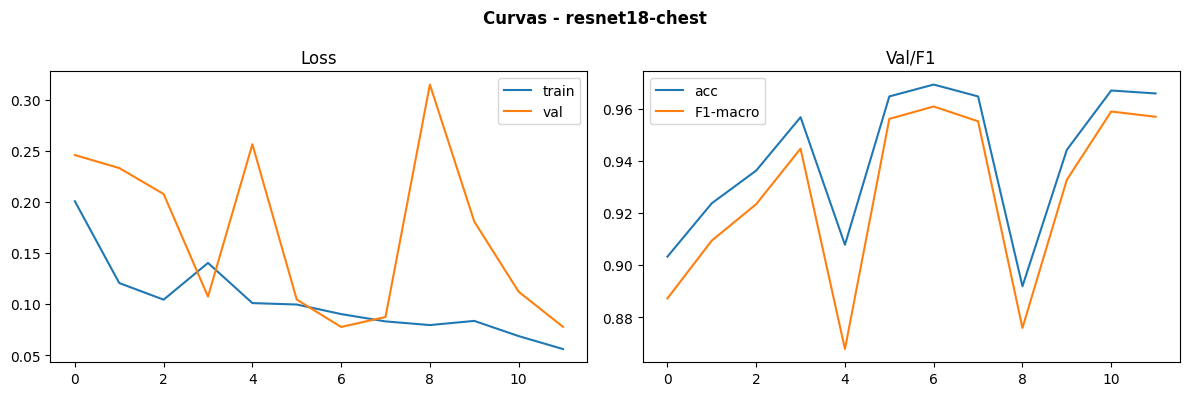


=== resnet18/chest ===
  Acc=0.9670  F1=0.9582  Sens=0.9576  Spec=0.9576  AUC=0.9929
  Inf=32.718ms  Params=11,178,574
              precision    recall  f1-score   support

      NORMAL       0.94      0.94      0.94       238
   PNEUMONIA       0.98      0.98      0.98       641

    accuracy                           0.97       879
   macro avg       0.96      0.96      0.96       879
weighted avg       0.97      0.97      0.97       879



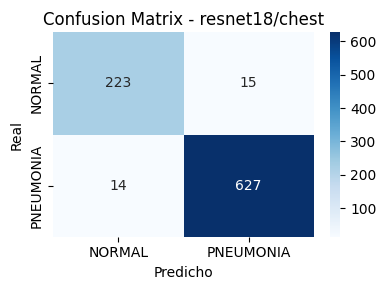

In [7]:
_mn='resnet18'
_ckpt=str(ckpt_chest/('resnet18_best.pt'))
_model=build_model(_mn,N_CHEST).to(DEVICE)
_hist=train_gpu(_model,chest_tr_l,chest_va_l,class_weights=None,max_epochs=50,patience=5,save_path=_ckpt)
plot_history(_hist,'resnet18-chest')
_model.load_state_dict(torch.load(_ckpt,map_location=DEVICE))
results_chest['resnet18']=compute_metrics(_model,chest_te_l,CHEST_NAMES,'resnet18/chest')
del _model; torch.cuda.empty_cache()


### HQC-CNN - Chest X-Ray

Ep 1/50:   0%|          | 0/65 [00:00<?, ?it/s]

Ep   1 | 89.5s | train=0.5462 | val=0.5058 | acc=0.7517 | F1=0.5016


Ep 2/50:   0%|          | 0/65 [00:00<?, ?it/s]

Ep   2 | 57.6s | train=0.4284 | val=0.3938 | acc=0.8747 | F1=0.8146


Ep 3/50:   0%|          | 0/65 [00:00<?, ?it/s]

...

Ep   7 | 57.5s | train=0.2113 | val=0.1843 | acc=0.9499 | F1=0.9380


Ep 8/50:   0%|          | 0/65 [00:00<?, ?it/s]

Ep   8 | 57.3s | train=0.1930 | val=0.2588 | acc=0.8918 | F1=0.8751


Ep 9/50:   0%|          | 0/65 [00:00<?, ?it/s]

Ep   9 | 57.4s | train=0.1929 | val=0.1836 | acc=0.9339 | F1=0.9204
Early stopping ep 9


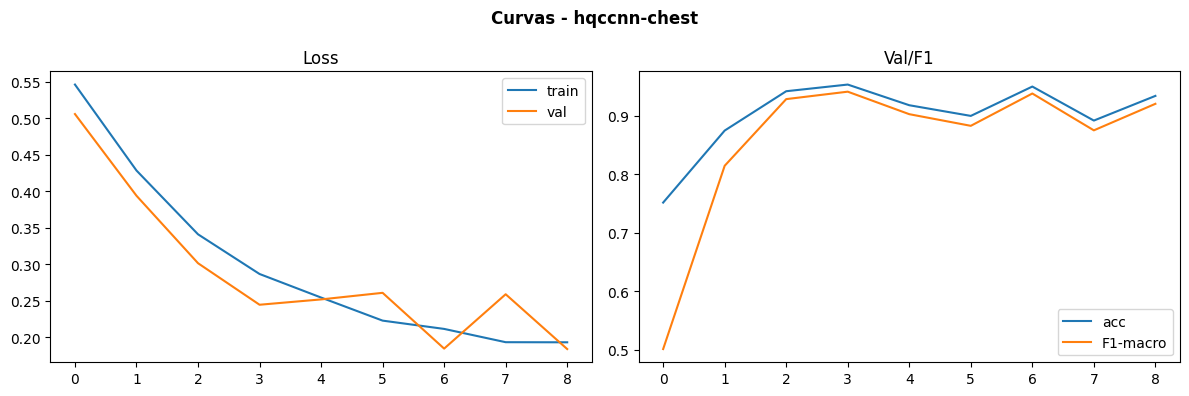


=== hqccnn/chest ===
  Acc=0.9386  F1=0.9236  Sens=0.9315  Spec=0.9315  AUC=0.9774
  Inf=11.601ms  Params=89,702
              precision    recall  f1-score   support

      NORMAL       0.87      0.92      0.89       238
   PNEUMONIA       0.97      0.95      0.96       641

    accuracy                           0.94       879
   macro avg       0.92      0.93      0.92       879
weighted avg       0.94      0.94      0.94       879



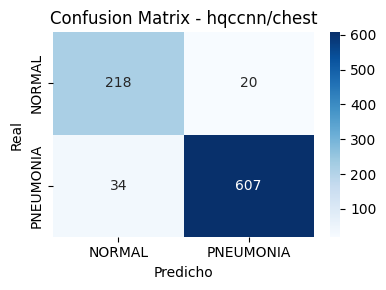

In [8]:
_mn='hqccnn'
_ckpt=str(ckpt_chest/('hqccnn_best.pt'))
_model=build_model(_mn,N_CHEST).to(DEVICE)
_hist=train_gpu(_model,chest_tr_l,chest_va_l,class_weights=None,max_epochs=50,patience=5,save_path=_ckpt)
plot_history(_hist,'hqccnn-chest')
_model.load_state_dict(torch.load(_ckpt,map_location=DEVICE))
results_chest['hqccnn']=compute_metrics(_model,chest_te_l,CHEST_NAMES,'hqccnn/chest')
del _model; torch.cuda.empty_cache()


### PEQML - Chest X-Ray

Ep 1/50:   0%|          | 0/65 [00:00<?, ?it/s]

Ep   1 | 41.1s | train=0.5460 | val=0.4971 | acc=0.8622 | F1=0.8235


Ep 2/50:   0%|          | 0/65 [00:00<?, ?it/s]

Ep   2 | 32.9s | train=0.4423 | val=0.3781 | acc=0.8850 | F1=0.8535


Ep 3/50:   0%|          | 0/65 [00:00<?, ?it/s]

...

Ep  17 | 35.3s | train=0.1786 | val=0.1866 | acc=0.9328 | F1=0.9176


Ep 18/50:   0%|          | 0/65 [00:00<?, ?it/s]

Ep  18 | 35.4s | train=0.1790 | val=0.1825 | acc=0.9328 | F1=0.9166


Ep 19/50:   0%|          | 0/65 [00:00<?, ?it/s]

Ep  19 | 35.0s | train=0.1803 | val=0.1775 | acc=0.9317 | F1=0.9149
Early stopping ep 19


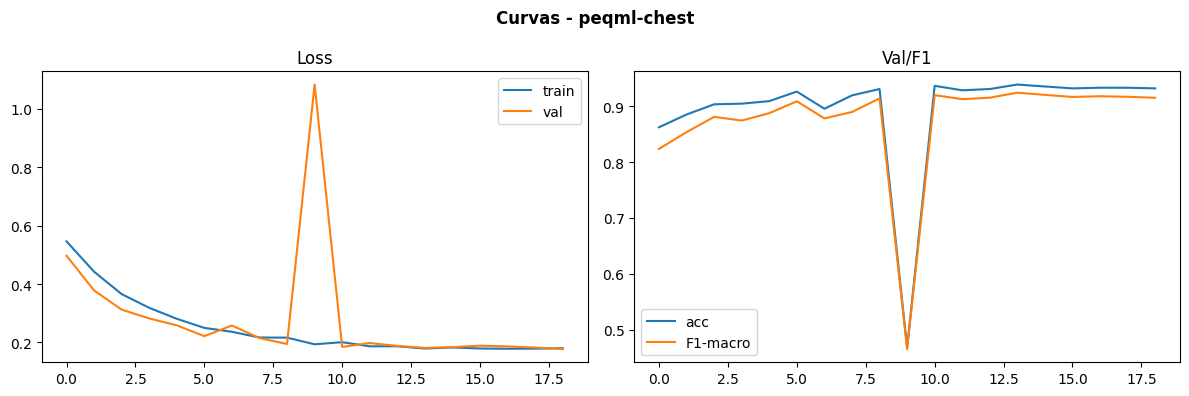


=== peqml/chest ===
  Acc=0.9283  F1=0.9112  Sens=0.9205  Spec=0.9205  AUC=0.9691
  Inf=13.225ms  Params=3,094
              precision    recall  f1-score   support

      NORMAL       0.84      0.90      0.87       238
   PNEUMONIA       0.96      0.94      0.95       641

    accuracy                           0.93       879
   macro avg       0.90      0.92      0.91       879
weighted avg       0.93      0.93      0.93       879



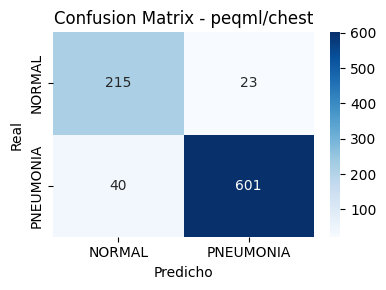

In [9]:
_mn='peqml'
_ckpt=str(ckpt_chest/('peqml_best.pt'))
_model=build_model(_mn,N_CHEST).to(DEVICE)
_hist=train_gpu(_model,chest_tr_l,chest_va_l,class_weights=None,max_epochs=50,patience=5,save_path=_ckpt)
plot_history(_hist,'peqml-chest')
_model.load_state_dict(torch.load(_ckpt,map_location=DEVICE))
results_chest['peqml']=compute_metrics(_model,chest_te_l,CHEST_NAMES,'peqml/chest')
del _model; torch.cuda.empty_cache()


### HQCINN-shallow - Chest X-Ray

Ep 1/50:   0%|          | 0/65 [00:00<?, ?it/s]

Ep   1 | 55.4s | train=0.7283 | val=0.6750 | acc=0.7677 | F1=0.5899


Ep 2/50:   0%|          | 0/65 [00:00<?, ?it/s]

Ep   2 | 30.3s | train=0.6055 | val=0.5407 | acc=0.8713 | F1=0.8229


Ep 3/50:   0%|          | 0/65 [00:00<?, ?it/s]

...

Ep  18 | 29.7s | train=0.1332 | val=0.1244 | acc=0.9601 | F1=0.9499


Ep 19/50:   0%|          | 0/65 [00:00<?, ?it/s]

Ep  19 | 29.7s | train=0.1285 | val=0.1661 | acc=0.9419 | F1=0.9299


Ep 20/50:   0%|          | 0/65 [00:00<?, ?it/s]

Ep  20 | 30.0s | train=0.1260 | val=0.1213 | acc=0.9647 | F1=0.9558
Early stopping ep 20


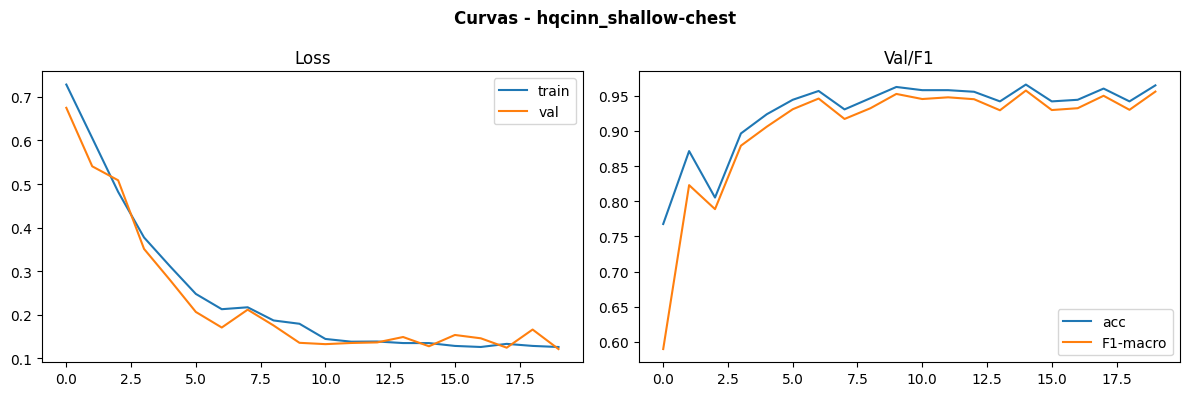


=== hqcinn_shallow/chest ===
  Acc=0.9454  F1=0.9316  Sens=0.9361  Spec=0.9361  AUC=0.9840
  Inf=11.237ms  Params=95,770
              precision    recall  f1-score   support

      NORMAL       0.89      0.92      0.90       238
   PNEUMONIA       0.97      0.96      0.96       641

    accuracy                           0.95       879
   macro avg       0.93      0.94      0.93       879
weighted avg       0.95      0.95      0.95       879



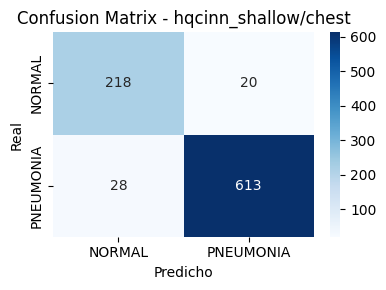

In [10]:
_mn='hqcinn_shallow'
_ckpt=str(ckpt_chest/('hqcinn_shallow_best.pt'))
_model=build_model(_mn,N_CHEST).to(DEVICE)
_hist=train_gpu(_model,chest_tr_l,chest_va_l,class_weights=None,max_epochs=50,patience=5,save_path=_ckpt)
plot_history(_hist,'hqcinn_shallow-chest')
_model.load_state_dict(torch.load(_ckpt,map_location=DEVICE))
results_chest['hqcinn_shallow']=compute_metrics(_model,chest_te_l,CHEST_NAMES,'hqcinn_shallow/chest')
del _model; torch.cuda.empty_cache()


### HQCINN-deep - Chest X-Ray

Ep 1/50:   0%|          | 0/65 [00:00<?, ?it/s]

Ep   1 | 49.9s | train=0.5235 | val=0.5423 | acc=0.7312 | F1=0.4305


Ep 2/50:   0%|          | 0/65 [00:00<?, ?it/s]

Ep   2 | 49.8s | train=0.4081 | val=0.4437 | acc=0.8280 | F1=0.8033


Ep 3/50:   0%|          | 0/65 [00:00<?, ?it/s]

...

Ep  23 | 47.7s | train=0.1314 | val=0.1349 | acc=0.9579 | F1=0.9477


Ep 24/50:   0%|          | 0/65 [00:00<?, ?it/s]

Ep  24 | 48.4s | train=0.1290 | val=0.1478 | acc=0.9499 | F1=0.9385


Ep 25/50:   0%|          | 0/65 [00:00<?, ?it/s]

Ep  25 | 48.2s | train=0.1291 | val=0.1334 | acc=0.9522 | F1=0.9410
Early stopping ep 25


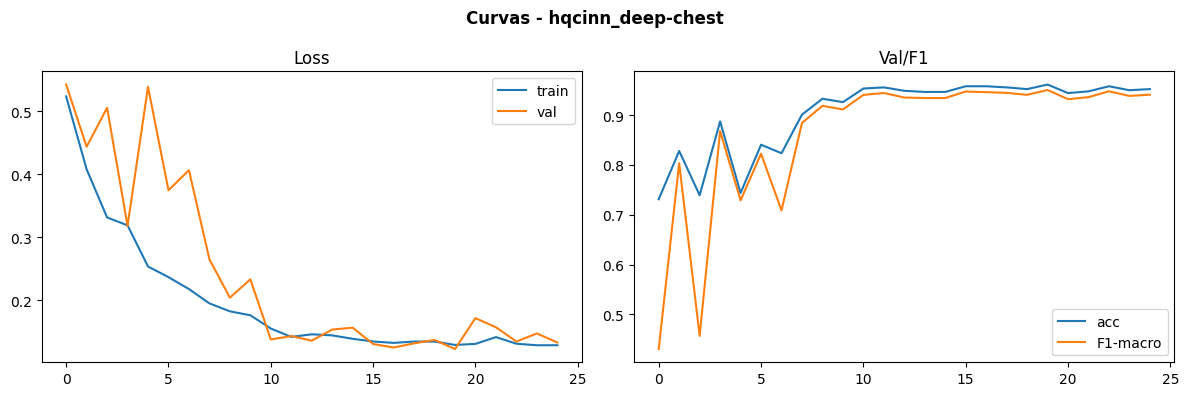


=== hqcinn_deep/chest ===
  Acc=0.9568  F1=0.9442  Sens=0.9360  Spec=0.9360  AUC=0.9847
  Inf=11.173ms  Params=95,794
              precision    recall  f1-score   support

      NORMAL       0.95      0.89      0.92       238
   PNEUMONIA       0.96      0.98      0.97       641

    accuracy                           0.96       879
   macro avg       0.95      0.94      0.94       879
weighted avg       0.96      0.96      0.96       879



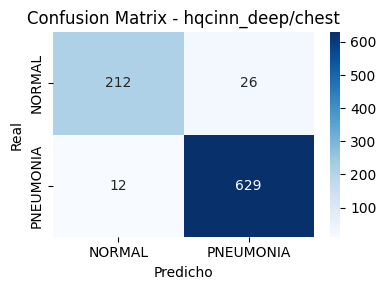

In [11]:
_mn='hqcinn_deep'
_ckpt=str(ckpt_chest/('hqcinn_deep_best.pt'))
_model=build_model(_mn,N_CHEST).to(DEVICE)
_hist=train_gpu(_model,chest_tr_l,chest_va_l,class_weights=None,max_epochs=50,patience=5,save_path=_ckpt)
plot_history(_hist,'hqcinn_deep-chest')
_model.load_state_dict(torch.load(_ckpt,map_location=DEVICE))
results_chest['hqcinn_deep']=compute_metrics(_model,chest_te_l,CHEST_NAMES,'hqcinn_deep/chest')
del _model; torch.cuda.empty_cache()


## DATASET 2: IQ-OTH/NCCD Lung Cancer

### ResNet-18 - Lung Cancer

Ep 1/50:   0%|          | 0/12 [00:00<?, ?it/s]

Ep   1 | 36.2s | train=0.9176 | val=0.7740 | acc=0.7273 | F1=0.6099


Ep 2/50:   0%|          | 0/12 [00:00<?, ?it/s]

Ep   2 | 2.7s | train=0.4628 | val=6.8137 | acc=0.5091 | F1=0.2249


Ep 3/50:   0%|          | 0/12 [00:00<?, ?it/s]

...

Ep  20 | 2.5s | train=0.0239 | val=0.2123 | acc=0.9333 | F1=0.8844


Ep 21/50:   0%|          | 0/12 [00:00<?, ?it/s]

Ep  21 | 2.4s | train=0.0292 | val=0.2364 | acc=0.9515 | F1=0.9102


Ep 22/50:   0%|          | 0/12 [00:00<?, ?it/s]

Ep  22 | 2.6s | train=0.0307 | val=0.2459 | acc=0.9455 | F1=0.9000
Early stopping ep 22


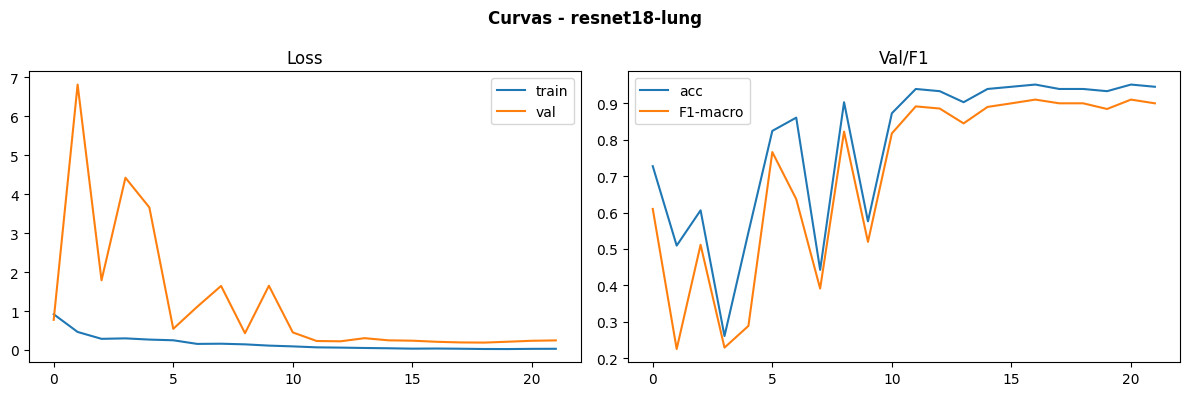


=== resnet18/lung ===
  Acc=0.9697  F1=0.9527  Sens=0.9351  Spec=0.9829  AUC=0.9990
  Inf=17.471ms  Params=11,178,579
              precision    recall  f1-score   support

      Benign       1.00      0.83      0.91        18
   Malignant       0.99      0.99      0.99        85
      Normal       0.94      0.98      0.96        62

    accuracy                           0.97       165
   macro avg       0.98      0.94      0.95       165
weighted avg       0.97      0.97      0.97       165



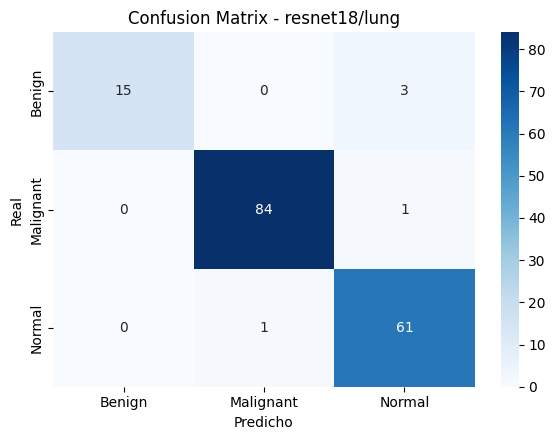

In [12]:
_mn='resnet18'
_ckpt=str(ckpt_lung/('resnet18_best.pt'))
_model=build_model(_mn,N_LUNG).to(DEVICE)
_hist=train_gpu(_model,lung_tr_l,lung_va_l,class_weights=lung_cw,max_epochs=50,patience=5,save_path=_ckpt)
plot_history(_hist,'resnet18-lung')
_model.load_state_dict(torch.load(_ckpt,map_location=DEVICE))
results_lung['resnet18']=compute_metrics(_model,lung_te_l,LUNG_NAMES,'resnet18/lung')
del _model; torch.cuda.empty_cache()


### HQC-CNN - Lung Cancer

Ep 1/50:   0%|          | 0/12 [00:00<?, ?it/s]

Ep   1 | 31.1s | train=1.1535 | val=1.1081 | acc=0.5091 | F1=0.2249


Ep 2/50:   0%|          | 0/12 [00:00<?, ?it/s]

Ep   2 | 11.4s | train=1.1000 | val=1.1107 | acc=0.5091 | F1=0.2249


Ep 3/50:   0%|          | 0/12 [00:00<?, ?it/s]

...

Ep   4 | 11.7s | train=1.0662 | val=1.1334 | acc=0.1333 | F1=0.0973


Ep 5/50:   0%|          | 0/12 [00:00<?, ?it/s]

Ep   5 | 11.5s | train=1.0481 | val=1.1403 | acc=0.1091 | F1=0.0656


Ep 6/50:   0%|          | 0/12 [00:00<?, ?it/s]

Ep   6 | 11.8s | train=1.0361 | val=1.1431 | acc=0.1091 | F1=0.0656
Early stopping ep 6


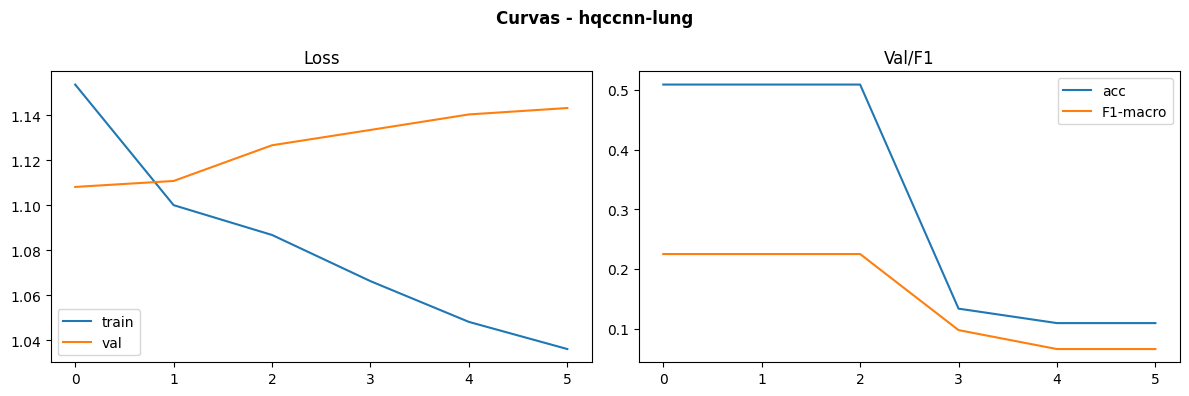


=== hqccnn/lung ===
  Acc=0.5152  F1=0.2267  Sens=0.3333  Spec=0.6667  AUC=0.4689
  Inf=9.355ms  Params=89,707
              precision    recall  f1-score   support

      Benign       0.00      0.00      0.00        18
   Malignant       0.52      1.00      0.68        85
      Normal       0.00      0.00      0.00        62

    accuracy                           0.52       165
   macro avg       0.17      0.33      0.23       165
weighted avg       0.27      0.52      0.35       165



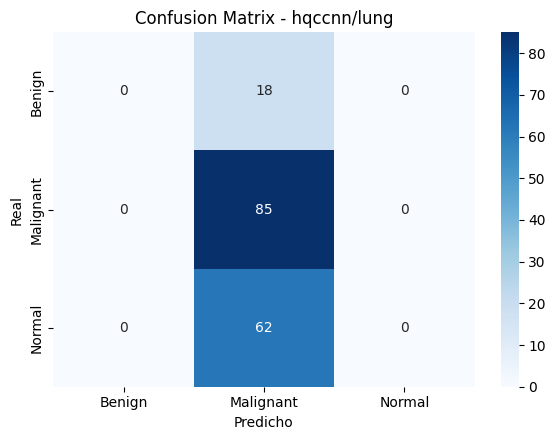

In [13]:
_mn='hqccnn'
_ckpt=str(ckpt_lung/('hqccnn_best.pt'))
_model=build_model(_mn,N_LUNG).to(DEVICE)
_hist=train_gpu(_model,lung_tr_l,lung_va_l,class_weights=lung_cw,max_epochs=50,patience=5,save_path=_ckpt)
plot_history(_hist,'hqccnn-lung')
_model.load_state_dict(torch.load(_ckpt,map_location=DEVICE))
results_lung['hqccnn']=compute_metrics(_model,lung_te_l,LUNG_NAMES,'hqccnn/lung')
del _model; torch.cuda.empty_cache()


### PEQML - Lung Cancer

Ep 1/50:   0%|          | 0/12 [00:00<?, ?it/s]

Ep   1 | 11.4s | train=1.2694 | val=1.0915 | acc=0.3818 | F1=0.1842


Ep 2/50:   0%|          | 0/12 [00:00<?, ?it/s]

Ep   2 | 6.8s | train=1.2453 | val=1.0866 | acc=0.3818 | F1=0.1842


Ep 3/50:   0%|          | 0/12 [00:00<?, ?it/s]

...

Ep   4 | 7.1s | train=1.1808 | val=1.0943 | acc=0.3818 | F1=0.1842


Ep 5/50:   0%|          | 0/12 [00:00<?, ?it/s]

Ep   5 | 7.3s | train=1.1038 | val=1.1429 | acc=0.3818 | F1=0.1842


Ep 6/50:   0%|          | 0/12 [00:00<?, ?it/s]

Ep   6 | 6.5s | train=1.0648 | val=1.1539 | acc=0.3818 | F1=0.1842
Early stopping ep 6


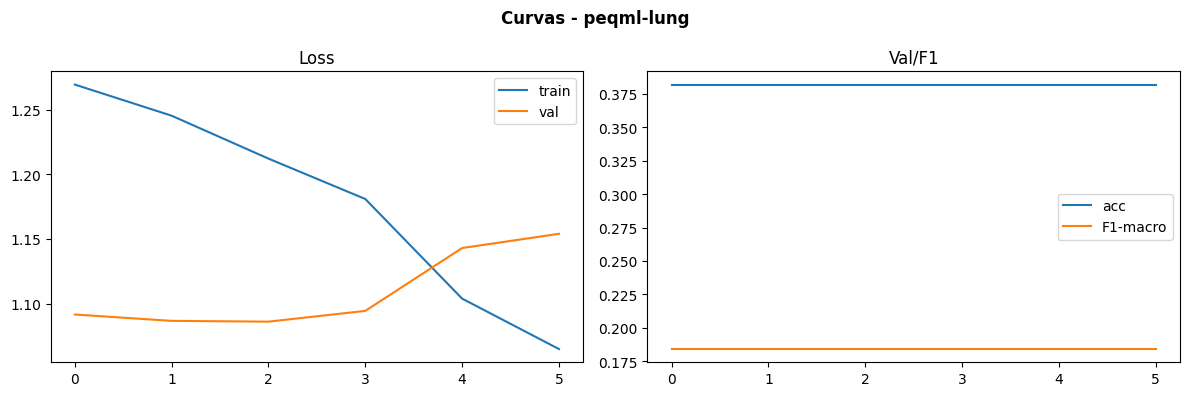


=== peqml/lung ===
  Acc=0.3758  F1=0.1821  Sens=0.3333  Spec=0.6667  AUC=0.4181
  Inf=8.066ms  Params=3,099
              precision    recall  f1-score   support

      Benign       0.00      0.00      0.00        18
   Malignant       0.00      0.00      0.00        85
      Normal       0.38      1.00      0.55        62

    accuracy                           0.38       165
   macro avg       0.13      0.33      0.18       165
weighted avg       0.14      0.38      0.21       165



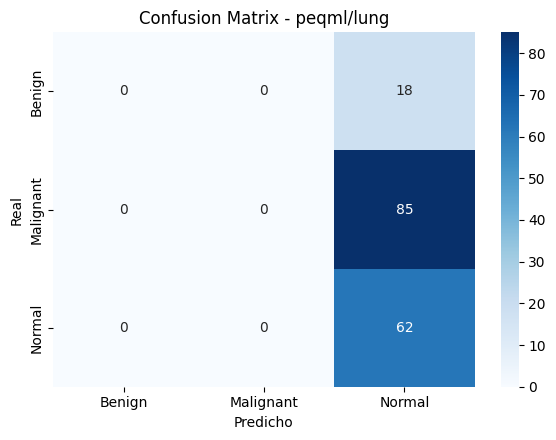

In [14]:
_mn='peqml'
_ckpt=str(ckpt_lung/('peqml_best.pt'))
_model=build_model(_mn,N_LUNG).to(DEVICE)
_hist=train_gpu(_model,lung_tr_l,lung_va_l,class_weights=lung_cw,max_epochs=50,patience=5,save_path=_ckpt)
plot_history(_hist,'peqml-lung')
_model.load_state_dict(torch.load(_ckpt,map_location=DEVICE))
results_lung['peqml']=compute_metrics(_model,lung_te_l,LUNG_NAMES,'peqml/lung')
del _model; torch.cuda.empty_cache()


### HQCINN-shallow - Lung Cancer

Ep 1/50:   0%|          | 0/12 [00:00<?, ?it/s]

Ep   1 | 21.5s | train=1.0609 | val=1.1111 | acc=0.2727 | F1=0.2444


Ep 2/50:   0%|          | 0/12 [00:00<?, ?it/s]

Ep   2 | 6.0s | train=1.0111 | val=1.1073 | acc=0.1152 | F1=0.0810


Ep 3/50:   0%|          | 0/12 [00:00<?, ?it/s]

...

Ep   6 | 6.0s | train=0.9425 | val=1.0180 | acc=0.3939 | F1=0.3652


Ep 7/50:   0%|          | 0/12 [00:00<?, ?it/s]

Ep   7 | 5.5s | train=0.9168 | val=1.1474 | acc=0.2000 | F1=0.1846


Ep 8/50:   0%|          | 0/12 [00:00<?, ?it/s]

Ep   8 | 5.9s | train=0.8791 | val=1.1276 | acc=0.5212 | F1=0.2472
Early stopping ep 8


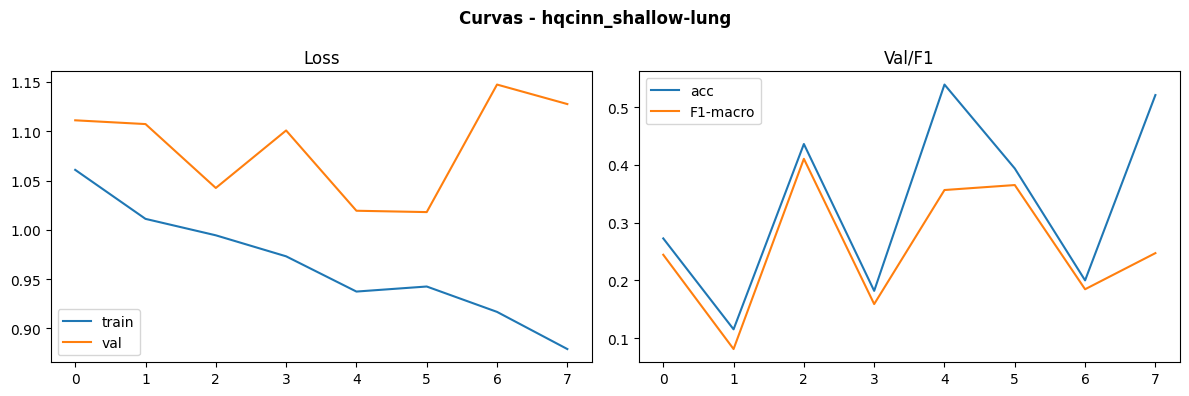


=== hqcinn_shallow/lung ===
  Acc=0.3697  F1=0.3483  Sens=0.4025  Spec=0.7206  AUC=0.5157
  Inf=8.234ms  Params=95,775
              precision    recall  f1-score   support

      Benign       0.12      0.44      0.19        18
   Malignant       1.00      0.25      0.40        85
      Normal       0.42      0.52      0.46        62

    accuracy                           0.37       165
   macro avg       0.51      0.40      0.35       165
weighted avg       0.68      0.37      0.40       165



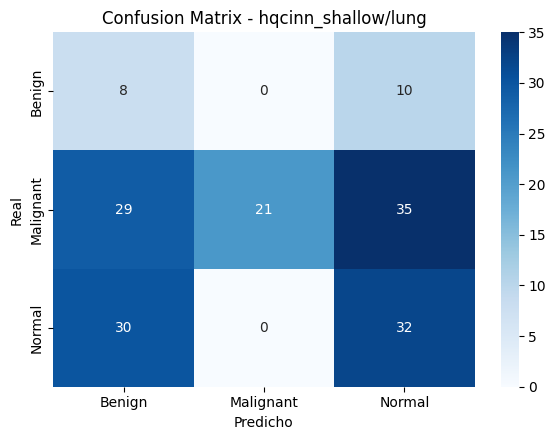

In [15]:
_mn='hqcinn_shallow'
_ckpt=str(ckpt_lung/('hqcinn_shallow_best.pt'))
_model=build_model(_mn,N_LUNG).to(DEVICE)
_hist=train_gpu(_model,lung_tr_l,lung_va_l,class_weights=lung_cw,max_epochs=50,patience=5,save_path=_ckpt)
plot_history(_hist,'hqcinn_shallow-lung')
_model.load_state_dict(torch.load(_ckpt,map_location=DEVICE))
results_lung['hqcinn_shallow']=compute_metrics(_model,lung_te_l,LUNG_NAMES,'hqcinn_shallow/lung')
del _model; torch.cuda.empty_cache()


### HQCINN-deep - Lung Cancer

Ep 1/50:   0%|          | 0/12 [00:00<?, ?it/s]

Ep   1 | 9.9s | train=1.2672 | val=1.1380 | acc=0.5091 | F1=0.2249


Ep 2/50:   0%|          | 0/12 [00:00<?, ?it/s]

Ep   2 | 9.7s | train=1.1703 | val=1.1313 | acc=0.5091 | F1=0.2249


Ep 3/50:   0%|          | 0/12 [00:00<?, ?it/s]

...

Ep   4 | 9.8s | train=1.0918 | val=1.1583 | acc=0.5091 | F1=0.2249


Ep 5/50:   0%|          | 0/12 [00:00<?, ?it/s]

Ep   5 | 9.7s | train=1.0538 | val=1.1624 | acc=0.2121 | F1=0.1775


Ep 6/50:   0%|          | 0/12 [00:00<?, ?it/s]

Ep   6 | 9.8s | train=1.0180 | val=1.1788 | acc=0.2485 | F1=0.2166
Early stopping ep 6


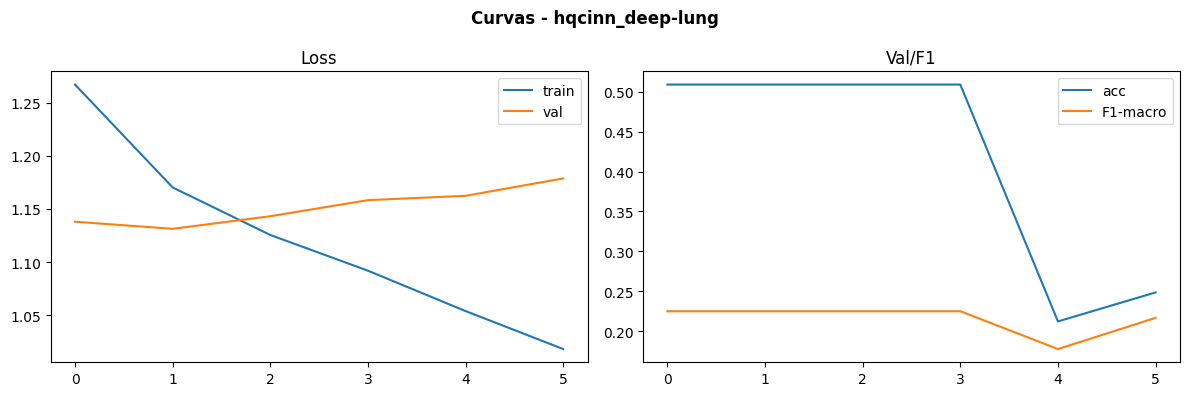


=== hqcinn_deep/lung ===
  Acc=0.5152  F1=0.2267  Sens=0.3333  Spec=0.6667  AUC=0.5335
  Inf=11.809ms  Params=95,799
              precision    recall  f1-score   support

      Benign       0.00      0.00      0.00        18
   Malignant       0.52      1.00      0.68        85
      Normal       0.00      0.00      0.00        62

    accuracy                           0.52       165
   macro avg       0.17      0.33      0.23       165
weighted avg       0.27      0.52      0.35       165



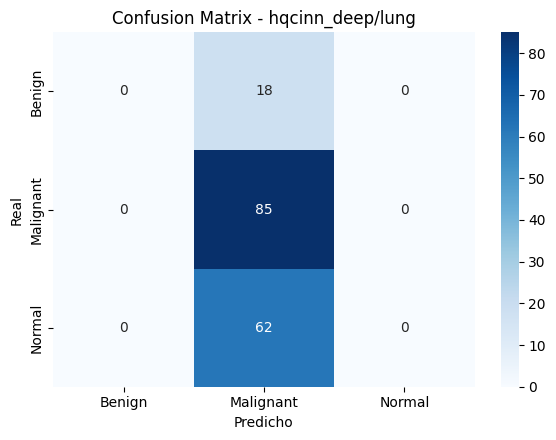

In [16]:
_mn='hqcinn_deep'
_ckpt=str(ckpt_lung/('hqcinn_deep_best.pt'))
_model=build_model(_mn,N_LUNG).to(DEVICE)
_hist=train_gpu(_model,lung_tr_l,lung_va_l,class_weights=lung_cw,max_epochs=50,patience=5,save_path=_ckpt)
plot_history(_hist,'hqcinn_deep-lung')
_model.load_state_dict(torch.load(_ckpt,map_location=DEVICE))
results_lung['hqcinn_deep']=compute_metrics(_model,lung_te_l,LUNG_NAMES,'hqcinn_deep/lung')
del _model; torch.cuda.empty_cache()


## 6 - Tablas y graficos comparativos


=== CHEST ===
                Accuracy  F1-macro  Sensibilidad  Especificidad     AUC  Inf(ms)    Params
Modelo                                                                                    
resnet18          0.9670    0.9582        0.9576         0.9576  0.9929   32.718  11178574
hqccnn            0.9386    0.9236        0.9315         0.9315  0.9774   11.601     89702
peqml             0.9283    0.9112        0.9205         0.9205  0.9691   13.225      3094
hqcinn_shallow    0.9454    0.9316        0.9361         0.9361  0.9840   11.237     95770
hqcinn_deep       0.9568    0.9442        0.9360         0.9360  0.9847   11.173     95794


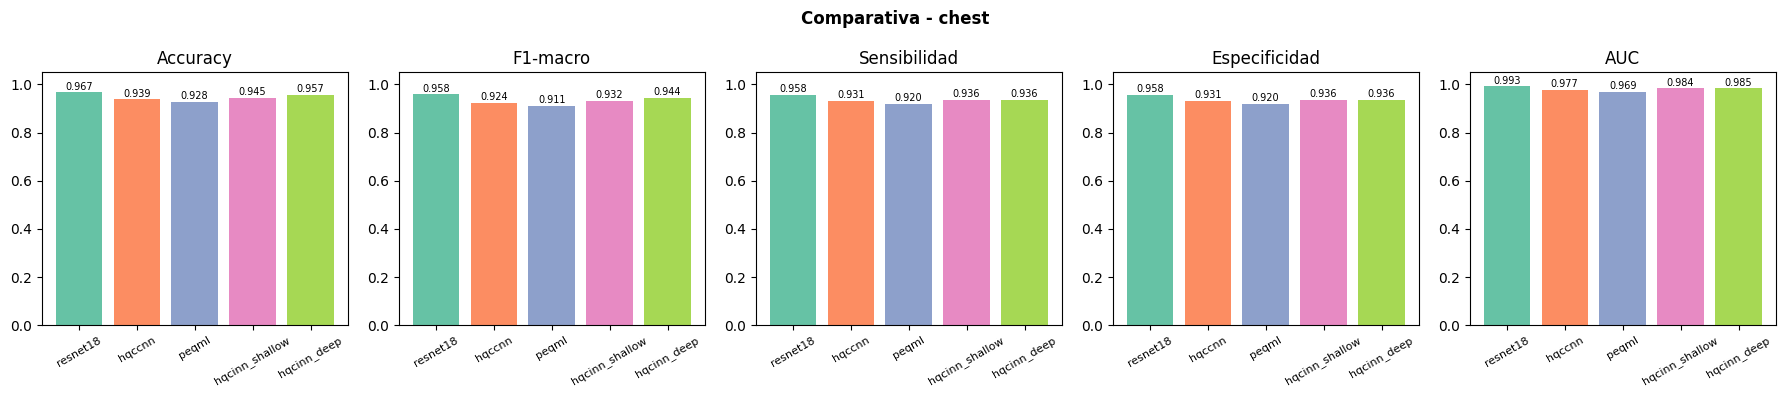


=== LUNG ===
                Accuracy  F1-macro  Sensibilidad  Especificidad     AUC  Inf(ms)    Params
Modelo                                                                                    
resnet18          0.9697    0.9527        0.9351         0.9829  0.9990   17.471  11178579
hqccnn            0.5152    0.2267        0.3333         0.6667  0.4689    9.355     89707
peqml             0.3758    0.1821        0.3333         0.6667  0.4181    8.066      3099
hqcinn_shallow    0.3697    0.3483        0.4025         0.7206  0.5157    8.234     95775
hqcinn_deep       0.5152    0.2267        0.3333         0.6667  0.5335   11.809     95799


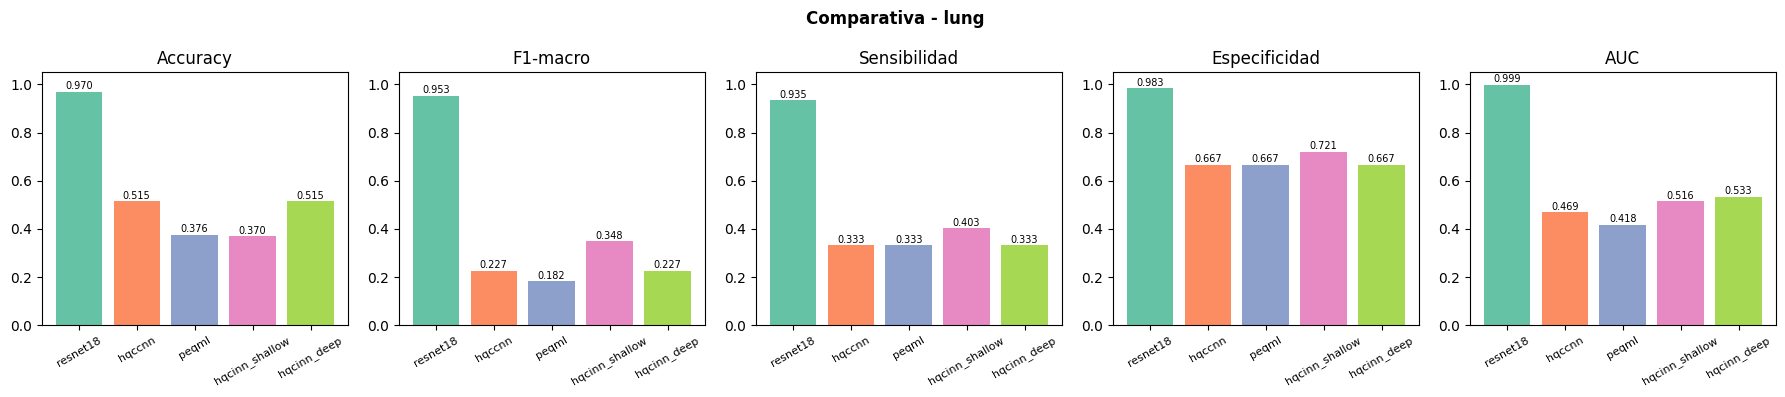

In [17]:
all_results={'chest':results_chest,'lung':results_lung}
for dsname in ['chest','lung']:
    rows=[]
    for mn,r in all_results[dsname].items():
        rows.append({'Modelo':mn,'Accuracy':round(r['acc'],4),'F1-macro':round(r['f1'],4),'Sensibilidad':round(r['sens'],4),'Especificidad':round(r['spec'],4),'AUC':round(r['auc'],4),'Inf(ms)':round(r['inf_ms'],3),'Params':r['params']})
    df=pd.DataFrame(rows).set_index('Modelo')
    print('\n===',dsname.upper(),'===');print(df.to_string())
    df.to_csv(BASE_DIR/('resultados_'+dsname+'.csv'))
    mets=['Accuracy','F1-macro','Sensibilidad','Especificidad','AUC']
    fig,axes=plt.subplots(1,len(mets),figsize=(18,4))
    fig.suptitle('Comparativa - '+dsname,fontweight='bold')
    pal=sns.color_palette('Set2',len(df))
    for ax,met in zip(axes,mets):
        vals=df[met].values;bars=ax.bar(df.index,vals,color=pal)
        ax.set_title(met);ax.set_ylim(0,1.05);ax.tick_params(axis='x',rotation=30,labelsize=8)
        for bar,v in zip(bars,vals): ax.text(bar.get_x()+bar.get_width()/2,v+0.01,'{:.3f}'.format(v),ha='center',fontsize=7)
    plt.tight_layout();plt.show()


## 7 - Analisis estadistico

In [18]:
def f1_boot(preds,labs,n=1000,seed=42):
    rng=np.random.default_rng(seed);sz=len(labs)
    return [f1_score(np.array(labs)[rng.integers(0,sz,sz)],np.array(preds)[rng.integers(0,sz,sz)],average='macro',zero_division=0) for _ in range(n)]
for dsname in ['chest','lung']:
    print('\n===',dsname.upper(),'===')
    dists={}
    for mn,r in all_results[dsname].items():
        dists[mn]=f1_boot(r['preds'],r['labs'])
        ci=np.percentile(dists[mn],[2.5,97.5])
        print('  {:<20} F1={:.4f}  IC95=[{:.4f},{:.4f}]'.format(mn,r['f1'],ci[0],ci[1]))
    f_stat,p_anova=stats.f_oneway(*dists.values())
    print('  ANOVA F={:.4f} p={:.6f} sig={}'.format(f_stat,p_anova,p_anova<0.05))
    pair_rows=[]
    for m1,m2 in combinations(list(dists.keys()),2):
        t,p=stats.ttest_ind(dists[m1],dists[m2])
        sig='*' if p<0.05 else ''
        pair_rows.append({'Par':m1+' vs '+m2,'t':round(t,4),'p':round(p,6),'sig':sig})
        print('  {} vs {}: t={:.4f} p={:.6f} {}'.format(m1,m2,t,p,sig))
    pd.DataFrame(pair_rows).to_csv(BASE_DIR/('ttest_'+dsname+'.csv'),index=False)



=== CHEST ===
  resnet18             F1=0.9582  IC95=[0.4662,0.5351]
  hqccnn               F1=0.9236  IC95=[0.4664,0.5374]
  peqml                F1=0.9112  IC95=[0.4669,0.5377]
  hqcinn_shallow       F1=0.9316  IC95=[0.4634,0.5344]
  hqcinn_deep          F1=0.9442  IC95=[0.4656,0.5356]
  ANOVA F=0.1150 p=0.977259 sig=False
  resnet18 vs hqccnn: t=0.5245 p=0.599992 
  resnet18 vs peqml: t=0.1595 p=0.873257 
  resnet18 vs hqcinn_shallow: t=0.0657 p=0.947647 
  resnet18 vs hqcinn_deep: t=0.4777 p=0.632888 
  hqccnn vs peqml: t=-0.3647 p=0.715392 
  hqccnn vs hqcinn_shallow: t=-0.4546 p=0.649474 
  hqccnn vs hqcinn_deep: t=-0.0444 p=0.964581 
  peqml vs hqcinn_shallow: t=-0.0926 p=0.926220 
  peqml vs hqcinn_deep: t=0.3187 p=0.750019 
  hqcinn_shallow vs hqcinn_deep: t=0.4085 p=0.682943 

=== LUNG ===
  resnet18             F1=0.9527  IC95=[0.2686,0.4093]
  hqccnn               F1=0.2267  IC95=[0.2025,0.2484]
  peqml                F1=0.1821  IC95=[0.1550,0.2083]
  hqcinn_shallow       

## 8 - Guardar JSON consolidado

In [19]:
summary={}
for ds in ['chest','lung']:
    summary[ds]={}
    for mn,r in all_results[ds].items():
        summary[ds][mn]={k:v for k,v in r.items() if k not in ('preds','labs','probs')}
out=BASE_DIR/'resultados_gpu.json'
with open(out,'w') as f: json.dump(summary,f,indent=2,default=str)
print('Guardado:',out)


Guardado: D:\CURSOS 2026 - 1\Cyberseguridad\jupyterlab\investigacion\resultados_gpu.json
